First visualization of some images from the dataset

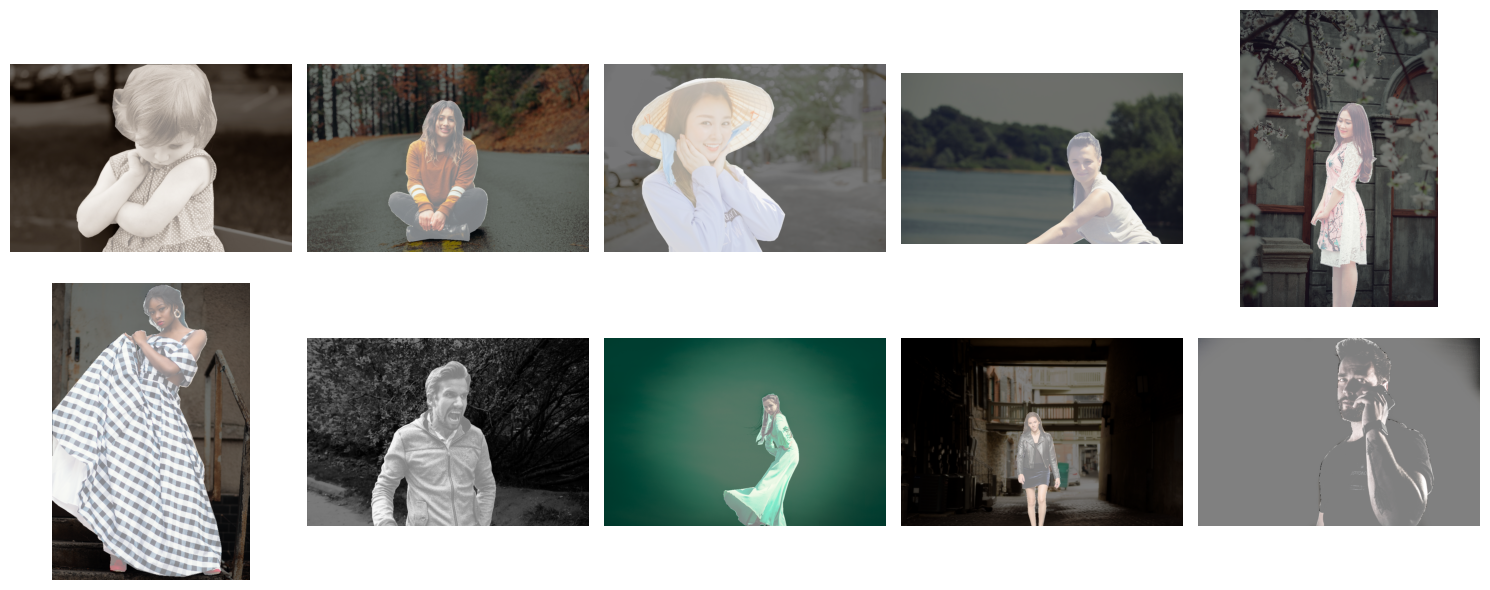

In [1]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

path = "./data/supervisely_person_clean_2667_img/images"
path_mask = "./data/supervisely_person_clean_2667_img/masks"


png_files = [f for f in os.listdir(path) if f.endswith('.png')]

random_images = random.sample(png_files, min(10, len(png_files)))


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, img_name in enumerate(random_images):
    img_path = os.path.join(path, img_name)
    img = Image.open(img_path)

    path_mask_img = os.path.join(path_mask, img_name)
    mask = Image.open(path_mask_img)
    
    axes[idx].imshow(img)
    axes[idx].imshow(mask, alpha=0.5) 
    axes[idx].axis('off')
    
    

plt.tight_layout()
plt.show()

todo:
prendi due pixel uno bianco e uno nero di un immagine. crea un immagine quadrata con estremi quei due punti. 
creare le background e image patches.

Poi creeremo un classifier che data una patch, stabilisce a che classe appartiene

In [ ]:
import numpy as np
import os
from PIL import Image

def pick_random_centers(mask, size=100, ignore=0):
    #Ignoring borders
    mask_ignored = mask.copy()
    mask_ignored[:ignore, :] = False
    mask_ignored[-ignore:, :] = False
    mask_ignored[:, :ignore] = False
    mask_ignored[:, -ignore:] = False
    
    rs, cs = np.where(mask_ignored)
    
    if len(rs) == 0:
        return np.array([]), np.array([])
    
    ix = np.random.randint(len(rs), size=min(size, len(rs)))
    return rs[ix], cs[ix]

def extract_patches_from_image(img_array, mask_array, n_patches_per_class, radius):
    patches = []
    labels = []
    
    # Converti maschera in booleano
    mask_bool = mask_array > 127
    
    # Estrai patch TRUE (persona)
    rs, cs = pick_random_centers(mask_bool, size=n_patches_per_class, ignore=radius)
    for r, c in zip(rs, cs):
        patch = img_array[r-radius:r+radius, c-radius:c+radius, :]
        patches.append(patch.flatten())
        labels.append(1)
    
    # Estrai patch FALSE (background)
    rs, cs = pick_random_centers(~mask_bool, size=n_patches_per_class, ignore=radius)
    for r, c in zip(rs, cs):
        patch = img_array[r-radius:r+radius, c-radius:c+radius, :]
        patches.append(patch.flatten())
        labels.append(0)
    
    return patches, labels


def create_patch_dataset(image_files, path_img, path_mask, radius, n_patches_per_class):
    X = []
    y = []
    
    for img_name in image_files:
        img = Image.open(os.path.join(path_img, img_name))
        mask = Image.open(os.path.join(path_mask, img_name))
        
        img_array = np.array(img)
        mask_array = np.array(mask)
        
        # patch extraction
        patches, labels = extract_patches_from_image(img_array, mask_array, 
                                                     n_patches_per_class, radius)
        
        X.extend(patches)
        y.extend(labels)
    
    return np.array(X), np.array(y)

